<h2><b> Librerías y configuraciones

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.decomposition import PCA

In [2]:
# Rutas
BASE_DIR = Path("..")

CENTROS = {
    "center_1": {
        "train": BASE_DIR / "preprocesamiento/output/center_1/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_1/preprocesamiento_test",
    },
    "center_2": {
        "train": BASE_DIR / "preprocesamiento/output/center_2/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_2/preprocesamiento_test",
    },
    "center_3": {
        "train": BASE_DIR / "preprocesamiento/output/center_3/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_3/preprocesamiento_test",
    },
    "center_4": {
        "train": BASE_DIR / "preprocesamiento/output/center_4/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_4/preprocesamiento_test",
    },
}

# Verificar rutas
print("Verificación de rutas:")
for nombre, rutas in CENTROS.items():
    train_ok = rutas["train"].exists()
    test_ok  = rutas["test"].exists()
    print(f"  {nombre} — train: {'OK' if train_ok else 'BAD'} | test: {'OK' if test_ok else 'BAD'}")

Verificación de rutas:
  center_1 — train: OK | test: OK
  center_2 — train: OK | test: OK
  center_3 — train: OK | test: OK
  center_4 — train: OK | test: OK


<h2><b> Conteo por centro y clase

In [ ]:
resumen = {}

for nombre, rutas in CENTROS.items():
    archivos_train = list(rutas["train"].glob("*.npy"))
    archivos_test  = list(rutas["test"].glob("*.npy"))

    stroke_train  = sum(1 for f in archivos_train if "STROKE"  in f.stem)
    control_train = sum(1 for f in archivos_train if "CONTROL" in f.stem)
    stroke_test   = sum(1 for f in archivos_test  if "STROKE"  in f.stem)
    control_test  = sum(1 for f in archivos_test  if "CONTROL" in f.stem)

    resumen[nombre] = {
        "stroke_train" : stroke_train,
        "control_train": control_train,
        "stroke_test"  : stroke_test,
        "control_test" : control_test,
        "total_train"  : len(archivos_train),
        "total_test"   : len(archivos_test),
        "total"        : len(archivos_train) + len(archivos_test),
    }

# Tabla
print(f"{'Centro':<12} {'STROKE train':>13} {'CONTROL train':>14} {'STROKE test':>12} {'CONTROL test':>13} {'Total':>7}")
print("─" * 65)
for nombre, r in resumen.items():
    print(f"{nombre:<12} {r['stroke_train']:>13} {r['control_train']:>14} {r['stroke_test']:>12} {r['control_test']:>13} {r['total']:>7}")

total_general = sum(r["total"] for r in resumen.values())
print("─" * 65)
print(f"{'TOTAL':<12} {sum(r['stroke_train'] for r in resumen.values()):>13} {sum(r['control_train'] for r in resumen.values()):>14} {sum(r['stroke_test'] for r in resumen.values()):>12} {sum(r['control_test'] for r in resumen.values()):>13} {total_general:>7}")

Centro        STROKE train  CONTROL train  STROKE test  CONTROL test   Total
─────────────────────────────────────────────────────────────────
center_1              1520           1520          380           380    3800
center_2               560            400          140           100    1200
center_3               427            252          107            64     850
center_4               692            588          173           147    1600
─────────────────────────────────────────────────────────────────
TOTAL                 3199           2760          800           691    7450


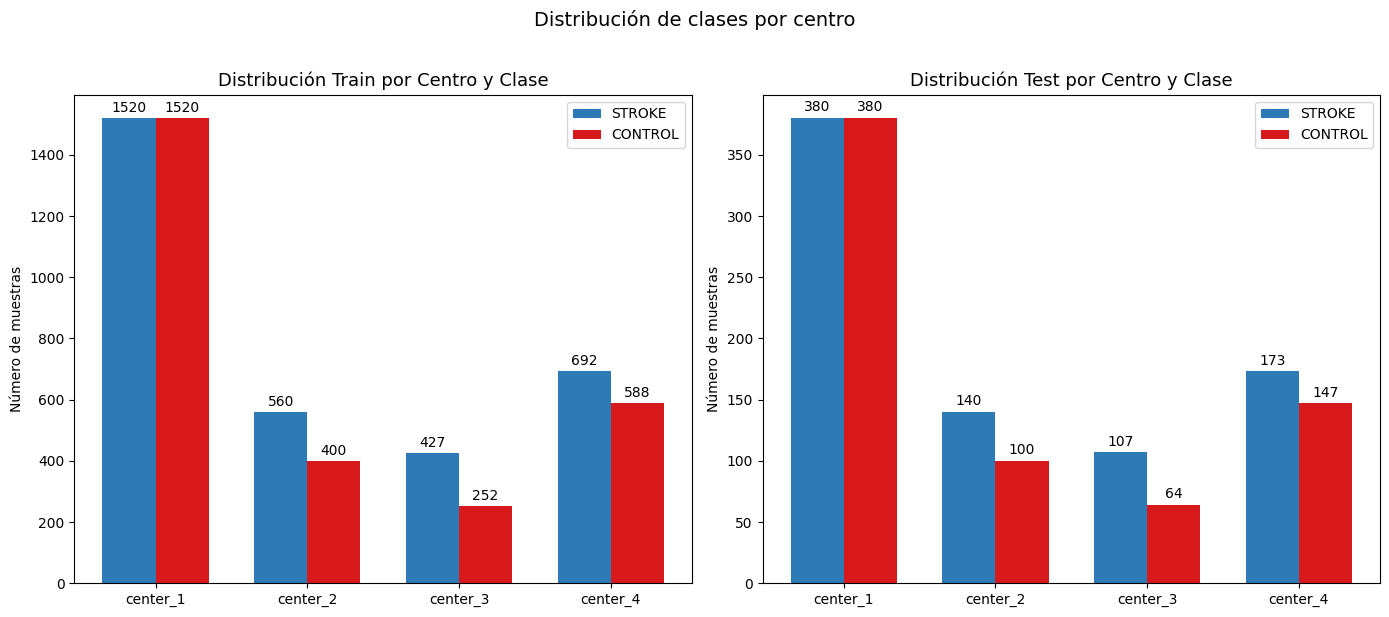


Desbalance por centro (% STROKE en train):
────────────────────────────────────────
  center_1  STROKE: 50.0% | CONTROL: 50.0%
  center_2  STROKE: 58.3% | CONTROL: 41.7%
  center_3  STROKE: 62.9% | CONTROL: 37.1%
  center_4  STROKE: 54.1% | CONTROL: 45.9%


In [ ]:
centros     = list(resumen.keys())
stroke_train  = [resumen[c]["stroke_train"]  for c in centros]
control_train = [resumen[c]["control_train"] for c in centros]
stroke_test   = [resumen[c]["stroke_test"]   for c in centros]
control_test  = [resumen[c]["control_test"]  for c in centros]

x     = np.arange(len(centros))
ancho = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train
bars1 = axes[0].bar(x - ancho/2, stroke_train,  ancho, label="STROKE",  color="#2c7bb6")
bars2 = axes[0].bar(x + ancho/2, control_train, ancho, label="CONTROL", color="#d7191c")

axes[0].set_title("Distribución Train por Centro y Clase", fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(centros)
axes[0].set_ylabel("Número de muestras")
axes[0].legend()

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)

# Test
bars3 = axes[1].bar(x - ancho/2, stroke_test,  ancho, label="STROKE",  color="#2c7bb6")
bars4 = axes[1].bar(x + ancho/2, control_test, ancho, label="CONTROL", color="#d7191c")

axes[1].set_title("Distribución Test por Centro y Clase", fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(centros)
axes[1].set_ylabel("Número de muestras")
axes[1].legend()

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)

plt.suptitle("Distribución de clases por centro", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Porcentaje de desbalance ---
print("\nDesbalance por centro (% STROKE en train):")
print("─" * 40)
for nombre, r in resumen.items():
    total_train = r["stroke_train"] + r["control_train"]
    pct_stroke  = r["stroke_train"] / total_train * 100
    pct_control = r["control_train"] / total_train * 100
    print(f"  {nombre}  STROKE: {pct_stroke:.1f}% | CONTROL: {pct_control:.1f}%")

<h2><b> Ejemplos visuales

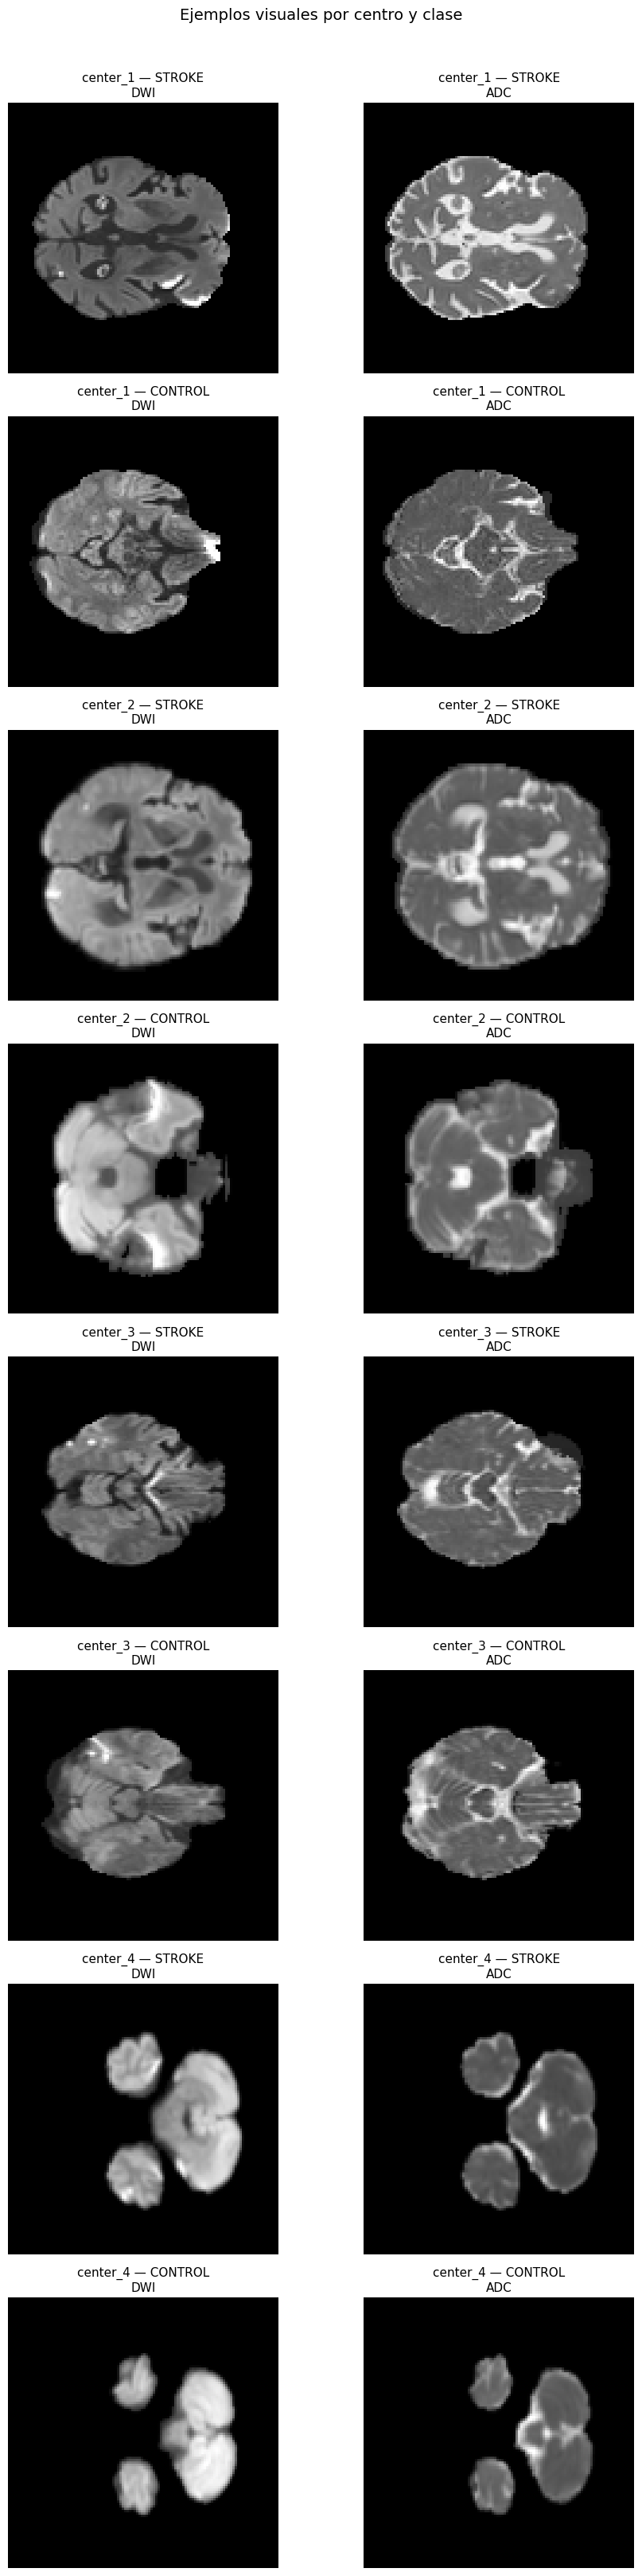

In [6]:
fig, axes = plt.subplots(8, 2, figsize=(10, 32))

fila = 0
for nombre, rutas in CENTROS.items():
    archivos = list(rutas["train"].glob("*.npy"))

    # Buscar un STROKE y un CONTROL
    stroke  = next((f for f in archivos if "STROKE"  in f.stem), None)
    control = next((f for f in archivos if "CONTROL" in f.stem), None)

    for clase, archivo in [("STROKE", stroke), ("CONTROL", control)]:
        img    = np.load(archivo)  # shape (2, 112, 112)
        dwi    = img[0]            # canal 0
        adc    = img[1]            # canal 1

        axes[fila, 0].imshow(dwi, cmap="gray")
        axes[fila, 0].set_title(f"{nombre} — {clase}\nDWI", fontsize=11)
        axes[fila, 0].axis("off")

        axes[fila, 1].imshow(adc, cmap="gray")
        axes[fila, 1].set_title(f"{nombre} — {clase}\nADC", fontsize=11)
        axes[fila, 1].axis("off")

        fila += 1

plt.suptitle("Ejemplos visuales por centro y clase", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

<h2><b> Histograma de intensidades

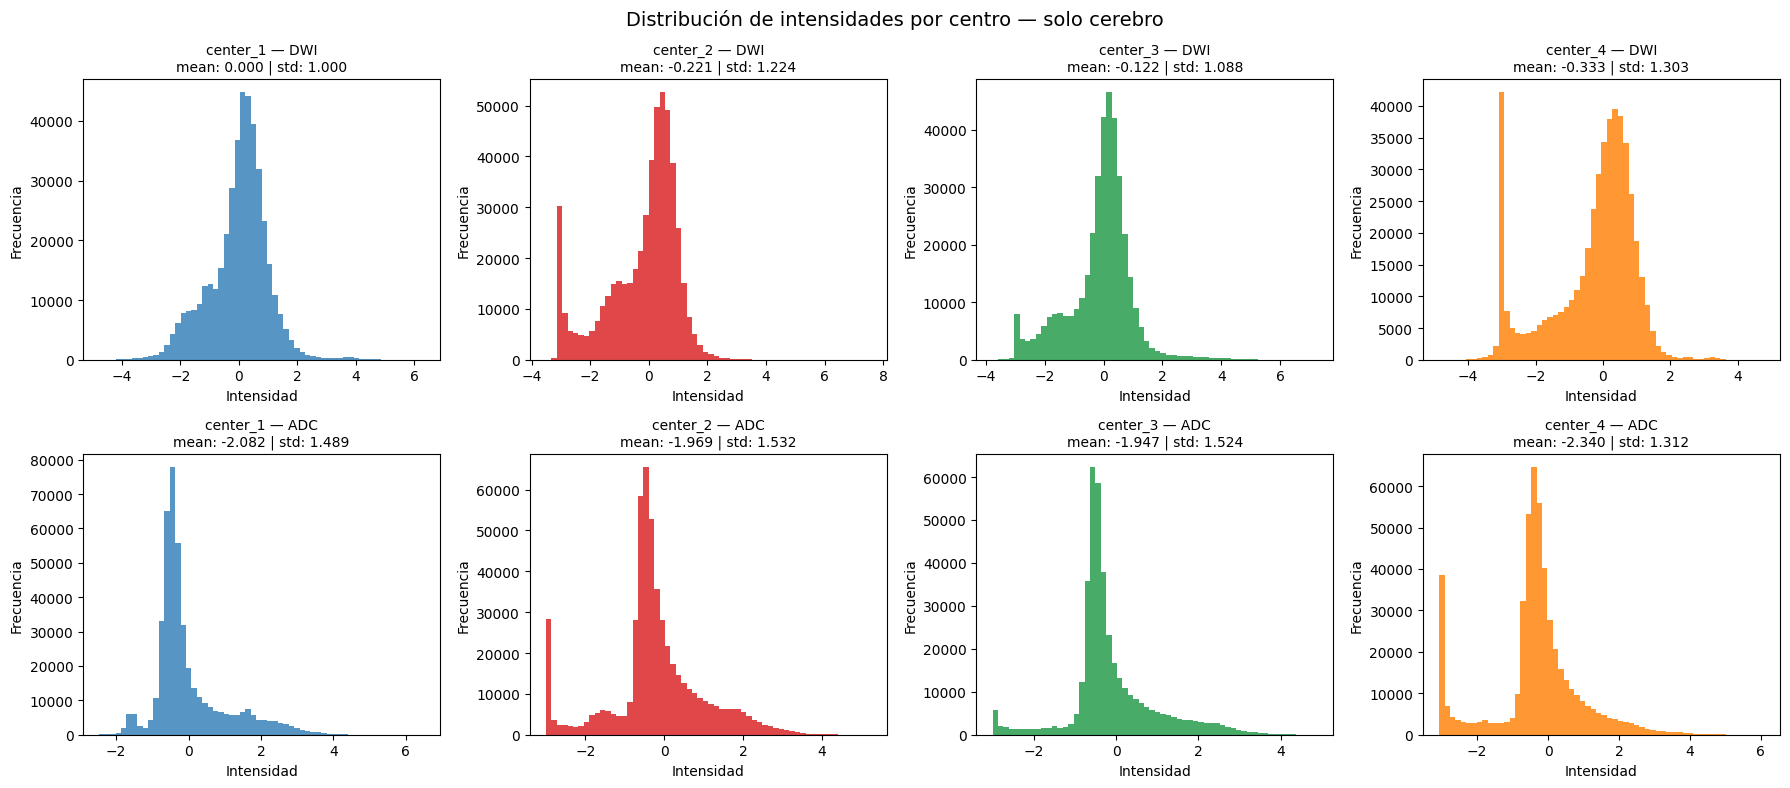

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

colores = {"center_1": "#2c7bb6", "center_2": "#d7191c", 
           "center_3": "#1a9641", "center_4": "#ff7f00"}

for col, (nombre, rutas) in enumerate(CENTROS.items()):
    archivos = list(rutas["train"].glob("*.npy"))[:100]  # muestra de 100

    pixeles_dwi = []
    pixeles_adc = []

    for f in archivos:
        img = np.load(f)
        dwi = img[0]
        adc = img[1]

        # Solo píxeles del cerebro
        pixeles_dwi.extend(dwi[dwi != -3.0].flatten())
        pixeles_adc.extend(adc[adc != -3.0].flatten())

    pixeles_dwi = np.array(pixeles_dwi)
    pixeles_adc = np.array(pixeles_adc)

    # DWI
    axes[0, col].hist(pixeles_dwi, bins=60, color=colores[nombre], 
                      alpha=0.8, edgecolor="none")
    axes[0, col].set_title(f"{nombre} — DWI\nmean: {pixeles_dwi.mean():.3f} | std: {pixeles_dwi.std():.3f}", 
                           fontsize=10)
    axes[0, col].set_xlabel("Intensidad")
    axes[0, col].set_ylabel("Frecuencia")

    # ADC
    axes[1, col].hist(pixeles_adc, bins=60, color=colores[nombre], 
                      alpha=0.8, edgecolor="none")
    axes[1, col].set_title(f"{nombre} — ADC\nmean: {adc.mean():.3f} | std: {adc.std():.3f}", 
                           fontsize=10)
    axes[1, col].set_xlabel("Intensidad")
    axes[1, col].set_ylabel("Frecuencia")

plt.suptitle("Distribución de intensidades por centro — solo cerebro", fontsize=14)
plt.tight_layout()
plt.show()

<h2><b> PCA

Shape matriz PCA: (400, 25088)
Varianza explicada: PC1=22.3% | PC2=12.8%


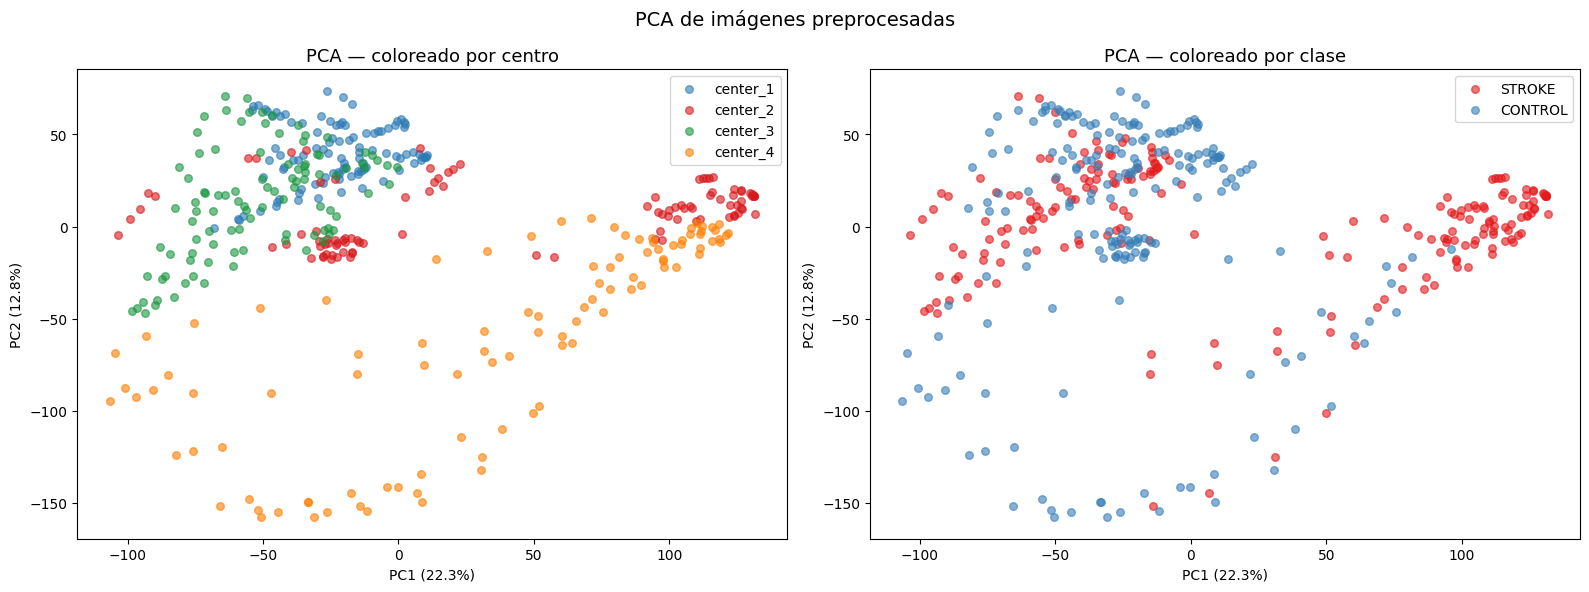

In [9]:
# PCA — reducir cada imagen a 2 dimensiones
# para ver si los centros forman grupos separados

# Cargar muestra de cada centro
N_POR_CENTRO = 100  # imágenes por centro

imagenes_flat = []  # imágenes aplanadas
etiquetas_centro = []  # a qué centro pertenece
etiquetas_clase  = []  # STROKE o CONTROL

for nombre, rutas in CENTROS.items():
    archivos = list(rutas["train"].glob("*.npy"))[:N_POR_CENTRO]
    
    for f in archivos:
        img = np.load(f)           # (2, 112, 112)
        imagenes_flat.append(img.flatten())  # 2×112×112 = 25088 números
        etiquetas_centro.append(nombre)
        etiquetas_clase.append("STROKE" if "STROKE" in f.stem else "CONTROL")

imagenes_flat    = np.array(imagenes_flat)
etiquetas_centro = np.array(etiquetas_centro)
etiquetas_clase  = np.array(etiquetas_clase)

print(f"Shape matriz PCA: {imagenes_flat.shape}")

# Aplicar PCA  reducir a 2 dimensiones
pca        = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(imagenes_flat)

print(f"Varianza explicada: PC1={pca.explained_variance_ratio_[0]*100:.1f}% | PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

# Grafico 1 — coloreado por centro
colores_centro = {
    "center_1": "#2c7bb6",
    "center_2": "#d7191c",
    "center_3": "#1a9641",
    "center_4": "#ff7f00"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for nombre in CENTROS.keys():
    mask = etiquetas_centro == nombre
    axes[0].scatter(
        componentes[mask, 0],
        componentes[mask, 1],
        c=colores_centro[nombre],
        label=nombre, alpha=0.6, s=30
    )

axes[0].set_title("PCA — coloreado por centro", fontsize=13)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].legend()

# Grafico 2 — coloreado por clase
colores_clase = {"STROKE": "#e41a1c", "CONTROL": "#377eb8"}

for clase in ["STROKE", "CONTROL"]:
    mask = etiquetas_clase == clase
    axes[1].scatter(
        componentes[mask, 0],
        componentes[mask, 1],
        c=colores_clase[clase],
        label=clase, alpha=0.6, s=30
    )

axes[1].set_title("PCA — coloreado por clase", fontsize=13)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].legend()

plt.suptitle("PCA de imágenes preprocesadas", fontsize=14)
plt.tight_layout()
plt.show()